<a href="https://colab.research.google.com/github/HarshMurarka28/PINN/blob/main/Burgerseqn_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyDOE

In [ ]:
"""
Physics-Informed Neural Network (PINN) for Burgers' Equation
============================================================
Based on: Raissi, Perdikaris & Karniadakis (2017)
"Physics Informed Deep Learning (Part I)"

PDE:  u_t + u*u_x - (0.01/pi)*u_xx = 0,  x in [-1,1], t in [0,1]
IC:   u(0, x) = -sin(pi*x)
BC:   u(t, -1) = u(t, 1) = 0

Network : 9 layers, 20 neurons/layer, tanh activation
Optimizer: L-BFGS (via scipy wrapper on TF variables)
Training data: Nu=100 boundary/initial points, Nf=10,000 collocation points

Install dependencies:
    pip install tensorflow numpy matplotlib scipy pyDOE
"""

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pyDOE import lhs
from scipy.optimize import minimize
from scipy.integrate import solve_ivp
from scipy.fft import fft, ifft, fftfreq


/tmp/ipykernel_5988/1222283625.py:22: DeprecationWarning: Importing `pyDOE` is deprecated and will be removed in a future release. Please import `pydoe` instead.
  from pyDOE import lhs


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# 1.  Neural Network Architecture
# ═════════════════════════════════════════════════════════════════════════════
class PINN(tf.keras.Model):
    """
    9-layer fully-connected network with tanh activations.
      Input  : (t, x) — 2 features
      Hidden : 7 layers × 20 neurons each
      Output : u(t, x) — scalar
    Total layers = 2 (in/out) + 7 hidden = 9  (matches paper exactly)
    """

    def __init__(self, layers):
        super().__init__()
        self.hidden_layers = []
        # Build hidden layers with Glorot (Xavier) initialisation
        for width in layers[1:-1]:
            self.hidden_layers.append(
                tf.keras.layers.Dense(
                    width,
                    activation="tanh",
                    kernel_initializer="glorot_normal",
                    bias_initializer="zeros",
                )
            )
        # Output layer — no activation
        self.out_layer = tf.keras.layers.Dense(
            layers[-1],
            kernel_initializer="glorot_normal",
            bias_initializer="zeros",
        )

    def call(self, t, x):
        """Forward pass.  t, x: tensors of shape (N, 1)."""
        inputs = tf.concat([t, x], axis=1)   # (N, 2)
        z = inputs
        for layer in self.hidden_layers:
            z = layer(z)
        return self.out_layer(z)             # (N, 1)

In [ ]:

# ═════════════════════════════════════════════════════════════════════════════
# 2.  Physics Residual  (automatic differentiation via tf.GradientTape)
# ═════════════════════════════════════════════════════════════════════════════
def burgers_residual(model, t_f, x_f):
    """
    Computes f = u_t + u*u_x - (0.01/pi)*u_xx
    using nested GradientTape for second-order derivatives.
    """
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([t_f, x_f])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([t_f, x_f])
            u = model(t_f, x_f)
        u_t = tape1.gradient(u, t_f)   # ∂u/∂t
        u_x = tape1.gradient(u, x_f)   # ∂u/∂x
    u_xx = tape2.gradient(u_x, x_f)    # ∂²u/∂x²

    del tape1, tape2
    f = u_t + u * u_x - (0.01 / np.pi) * u_xx
    return f

In [ ]:


# ═════════════════════════════════════════════════════════════════════════════
# 3.  Loss Function
# ═════════════════════════════════════════════════════════════════════════════
def compute_loss(model, t_u, x_u, u_u, t_f, x_f):
    """
    Total loss = MSE_u  +  MSE_f
      MSE_u : mean squared error on IC + BC data
      MSE_f : mean squared error of PDE residual at collocation points
    """
    # Data loss
    u_pred = model(t_u, x_u)
    mse_u  = tf.reduce_mean(tf.square(u_pred - u_u))

    # Physics loss
    f_pred = burgers_residual(model, t_f, x_f)
    mse_f  = tf.reduce_mean(tf.square(f_pred))

    return mse_u + mse_f, mse_u, mse_f



In [ ]:

# ═════════════════════════════════════════════════════════════════════════════
# 4.  Training Data Generation
# ═════════════════════════════════════════════════════════════════════════════
def generate_training_data(Nu=100, Nf=10_000):
    """
    Returns:
      X_u  (Nu, 2)  — IC + BC training points  [t, x]
      U_u  (Nu, 1)  — corresponding u values
      X_f  (Nf, 2)  — collocation points        [t, x]
    """
    lb = np.array([0.0, -1.0])
    ub = np.array([1.0,  1.0])

    # ── Collocation points via Latin Hypercube Sampling ──
    X_f = lb + (ub - lb) * lhs(2, Nf)

    # ── Initial condition: t=0, u(0,x) = -sin(pi*x) ──
    x_ic = np.linspace(-1, 1, 200)[:, None]
    t_ic = np.zeros_like(x_ic)
    u_ic = -np.sin(np.pi * x_ic)

    # ── Boundary conditions: u(t,-1)=0, u(t,1)=0 ──
    t_bc_l = np.random.uniform(0, 1, (50, 1))
    t_bc_r = np.random.uniform(0, 1, (50, 1))
    x_bc_l = -np.ones((50, 1))
    x_bc_r =  np.ones((50, 1))
    u_bc   =  np.zeros((100, 1))

    X_icbc = np.vstack([
        np.hstack([t_ic,   x_ic]),
        np.hstack([t_bc_l, x_bc_l]),
        np.hstack([t_bc_r, x_bc_r]),
    ])
    U_icbc = np.vstack([u_ic, u_bc])

    # Randomly subsample Nu points
    idx  = np.random.choice(X_icbc.shape[0], Nu, replace=False)
    X_u  = X_icbc[idx]
    U_u  = U_icbc[idx]

    return X_u, U_u, X_f


def to_tf(arr):
    """Convert numpy array to float32 TF tensor."""
    return tf.constant(arr, dtype=tf.float32)


In [ ]:

# ═════════════════════════════════════════════════════════════════════════════
# 5.  L-BFGS Training  (scipy wrapper around TF variables)
# ═════════════════════════════════════════════════════════════════════════════
class LBFGSTrainer:
    """
    Wraps scipy.optimize.minimize (L-BFGS-B) around a TF model.
    Flattens all trainable variables into a single 1-D numpy vector
    for scipy, then unpacks after each step.
    """

    def __init__(self, model, t_u, x_u, u_u, t_f, x_f):
        self.model = model
        self.t_u, self.x_u, self.u_u = t_u, x_u, u_u
        self.t_f, self.x_f           = t_f, x_f
        self.iter = 0
        self.loss_history = []

        # Build the shapes list so we can pack/unpack variables
        self.shapes   = [v.shape for v in model.trainable_variables]
        self.n_params = sum(np.prod(s) for s in self.shapes)
        print(f"Total trainable parameters: {self.n_params}")

    # ── Pack TF variables → 1-D numpy array ──────────────────────────────
    def _pack(self):
        return np.concatenate(
            [v.numpy().flatten() for v in self.model.trainable_variables]
        )

    # ── Unpack 1-D numpy array → TF variables ────────────────────────────
    def _unpack(self, flat):
        offset = 0
        for var, shape in zip(self.model.trainable_variables, self.shapes):
            size = np.prod(shape)
            var.assign(flat[offset: offset + size].reshape(shape))
            offset += size

    # ── Compute loss + gradients, return as numpy (for scipy) ────────────
    def loss_and_grad(self, flat_params):
        self._unpack(flat_params)

        with tf.GradientTape() as tape:
            loss, mse_u, mse_f = compute_loss(
                self.model,
                self.t_u, self.x_u, self.u_u,
                self.t_f, self.x_f
            )

        grads     = tape.gradient(loss, self.model.trainable_variables)
        flat_grad = np.concatenate([g.numpy().flatten() for g in grads])

        loss_val = loss.numpy().astype(np.float64)
        self.iter += 1

        if self.iter % 500 == 0:
            print(f"  Iter {self.iter:6d} | Loss: {loss_val:.3e} "
                  f"| MSE_u: {mse_u.numpy():.3e} "
                  f"| MSE_f: {mse_f.numpy():.3e}")
            self.loss_history.append(loss_val)

        return loss_val, flat_grad.astype(np.float64)

    # ── Run optimisation ──────────────────────────────────────────────────
    def train(self, max_iter=50_000):
        print("\nTraining with L-BFGS-B ...")
        x0 = self._pack().astype(np.float64)
        result = minimize(
            self.loss_and_grad,
            x0,
            method="L-BFGS-B",
            jac=True,
            options={
                "maxiter":  max_iter,
                "maxfun":   max_iter,
                "ftol":     1e-12,
                "gtol":     1e-8,
                "eps":      1e-8,
                "disp":     False,
            },
        )
        self._unpack(result.x)          # load best weights back into model
        print(f"Optimisation finished — {result.message}")
        print(f"Final loss: {result.fun:.3e}\n")
        return self.loss_history



In [ ]:

# ═════════════════════════════════════════════════════════════════════════════
# 6.  Reference Solution  (pseudo-spectral + RK45)
# ═════════════════════════════════════════════════════════════════════════════
def compute_reference(t_vals, x_vals):
    """Pseudo-spectral reference solution for Burgers' equation."""

    N      = 512
    x_spec = np.linspace(-1, 1, N, endpoint=False)
    kx_raw = fftfreq(N, d=1.0 / N)
    kx     = np.pi * kx_raw            # rescale for domain length 2

    u0_hat = fft(-np.sin(np.pi * x_spec))

    def rhs(t, u_hat):
        u   = np.real(ifft(u_hat))
        ux  = np.real(ifft(1j * kx * u_hat))
        return -fft(u * ux) - (0.01 / np.pi) * (kx ** 2) * u_hat

    sol = solve_ivp(rhs, [0, 1], u0_hat, t_eval=t_vals,
                    method="RK45", rtol=1e-8, atol=1e-9, max_step=0.005)

    Nx, Nt = len(x_vals), len(t_vals)
    U_exact = np.zeros((Nx, Nt))
    for i in range(Nt):
        u_full = np.real(ifft(sol.y[:, i]))
        U_exact[:, i] = np.interp(x_vals, x_spec, u_full)

    return U_exact



In [ ]:

# ═════════════════════════════════════════════════════════════════════════════
# 7.  Evaluation & Plotting  (reproduces Figure 1 from the paper)
# ═════════════════════════════════════════════════════════════════════════════
def evaluate_and_plot(model, loss_history):
    Nt, Nx = 200, 256
    t_vals = np.linspace(0, 1,  Nt)
    x_vals = np.linspace(-1, 1, Nx)
    T, X   = np.meshgrid(t_vals, x_vals)       # (Nx, Nt)

    t_flat = tf.constant(T.flatten()[:, None], dtype=tf.float32)
    x_flat = tf.constant(X.flatten()[:, None], dtype=tf.float32)
    u_pred = model(t_flat, x_flat).numpy().reshape(Nx, Nt)

    print("Computing reference solution …")
    U_exact = compute_reference(t_vals, x_vals)

    # Relative L2 error
    rel_err = np.linalg.norm(u_pred - U_exact) / np.linalg.norm(U_exact)
    print(f"\nRelative L2 error : {rel_err:.2e}  (paper target ~6.7e-4)")

    # ── Figure: spatio-temporal map + 3 snapshots ──
    fig = plt.figure(figsize=(14, 8))
    fig.suptitle(
        f"PINN — Burgers' Equation (Continuous Time, TensorFlow)\n"
        f"Relative L² error = {rel_err:.2e}",
        fontsize=13,
    )

    # Top panel — full u(t,x) map
    ax_top = fig.add_axes([0.08, 0.53, 0.86, 0.37])
    im = ax_top.pcolormesh(T, X, u_pred, shading="auto",
                           cmap="RdBu_r", vmin=-0.8, vmax=0.8)
    plt.colorbar(im, ax=ax_top, fraction=0.02, pad=0.01)
    ax_top.set_xlabel("t", fontsize=11)
    ax_top.set_ylabel("x", fontsize=11)
    ax_top.set_title("Predicted  u(t, x)", fontsize=11)
    for t_s in [0.25, 0.50, 0.75]:
        ax_top.axvline(t_s, color="white", lw=1.2, ls="--")

    # Bottom panels — snapshots at t=0.25, 0.50, 0.75
    snap_times = [0.25, 0.50, 0.75]
    for k, t_s in enumerate(snap_times):
        ax = fig.add_axes([0.07 + k * 0.31, 0.06, 0.26, 0.38])
        idx = np.argmin(np.abs(t_vals - t_s))
        ax.plot(x_vals, U_exact[:, idx], "b-",  lw=2,   label="Exact")
        ax.plot(x_vals, u_pred[:, idx],  "r--", lw=1.5, label="Prediction")
        ax.set_title(f"t = {t_s}", fontsize=10)
        ax.set_xlabel("x"); ax.set_ylabel("u(t,x)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    out_path = "/content/pinn_burgers_tf_result.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Plot saved → {out_path}")
    plt.show()

    # ── Loss curve ──
    if loss_history:
        fig2, ax2 = plt.subplots(figsize=(7, 4))
        ax2.semilogy(
            [i * 500 for i in range(1, len(loss_history) + 1)],
            loss_history, "b-o", ms=4
        )
        ax2.set_xlabel("Iteration"); ax2.set_ylabel("Total Loss")
        ax2.set_title("Training Loss (L-BFGS-B)")
        ax2.grid(True, alpha=0.3)
        loss_path = "/content/pinn_burgers_tf_loss.png"
        plt.savefig(loss_path, dpi=150, bbox_inches="tight")
        print(f"Loss curve saved → {loss_path}")
        plt.show()



Warm-up with Adam (1000 steps) ...
  Adam step  200 | Loss: 9.817e-02
  Adam step  400 | Loss: 7.147e-02
  Adam step  600 | Loss: 5.875e-02
  Adam step  800 | Loss: 4.477e-02
  Adam step 1000 | Loss: 2.411e-02
Total trainable parameters: 2601

Training with L-BFGS-B ...


/tmp/ipykernel_5988/2983969926.py:66: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


  Iter    500 | Loss: 6.264e-03 | MSE_u: 2.895e-03 | MSE_f: 3.369e-03
  Iter   1000 | Loss: 1.474e-03 | MSE_u: 6.320e-04 | MSE_f: 8.416e-04
  Iter   1500 | Loss: 6.758e-04 | MSE_u: 2.919e-04 | MSE_f: 3.839e-04
  Iter   2000 | Loss: 3.622e-04 | MSE_u: 1.429e-04 | MSE_f: 2.192e-04
  Iter   2500 | Loss: 2.448e-04 | MSE_u: 1.024e-04 | MSE_f: 1.424e-04
  Iter   3000 | Loss: 1.619e-04 | MSE_u: 5.186e-05 | MSE_f: 1.100e-04
  Iter   3500 | Loss: 1.349e-04 | MSE_u: 4.592e-05 | MSE_f: 8.896e-05
  Iter   4000 | Loss: 1.075e-04 | MSE_u: 3.954e-05 | MSE_f: 6.797e-05
  Iter   4500 | Loss: 9.119e-05 | MSE_u: 3.480e-05 | MSE_f: 5.639e-05
  Iter   5000 | Loss: 7.585e-05 | MSE_u: 2.739e-05 | MSE_f: 4.845e-05
  Iter   5500 | Loss: 6.851e-05 | MSE_u: 2.355e-05 | MSE_f: 4.496e-05
  Iter   6000 | Loss: 5.857e-05 | MSE_u: 1.599e-05 | MSE_f: 4.258e-05
Optimisation finished — STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
Final loss: 5.855e-05

Computing reference solution …

Relative L2 error : 8.89e-03  (p

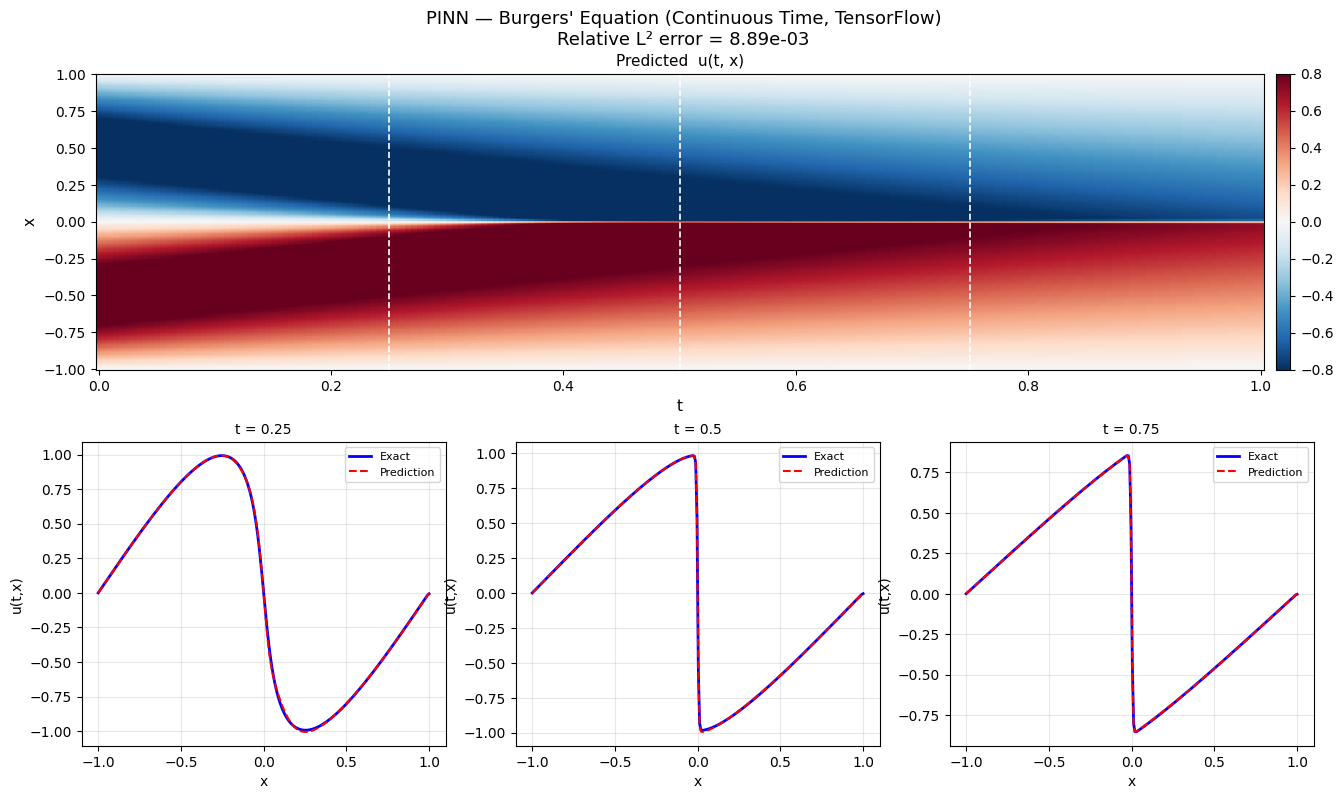

Loss curve saved → /content/pinn_burgers_tf_loss.png


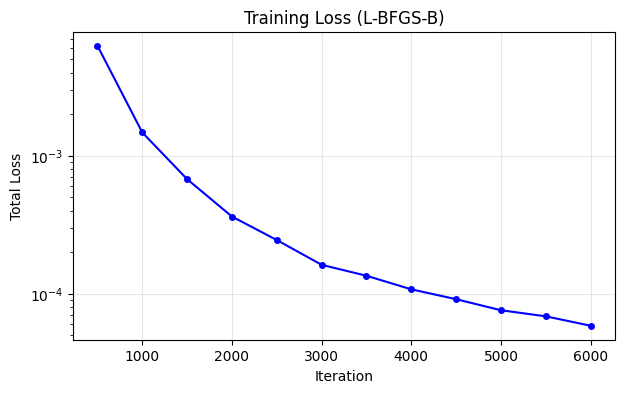

In [ ]:

# ═════════════════════════════════════════════════════════════════════════════
# 8.  Entry Point
# ═════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    # ── Build model — [2, 20,20,20,20,20,20,20, 1]  (9 layers) ──
    layers = [2] + [20] * 7 + [1]
    model  = PINN(layers)

    # ── Prepare data ──
    X_u, U_u, X_f = generate_training_data(Nu=100, Nf=10_000)

    t_u = to_tf(X_u[:, 0:1]);  x_u = to_tf(X_u[:, 1:2]);  u_u = to_tf(U_u)
    t_f = to_tf(X_f[:, 0:1]);  x_f = to_tf(X_f[:, 1:2])

    # ── Warm-up: a few Adam steps help L-BFGS converge faster ──
    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=1e-3)
    print("Warm-up with Adam (1000 steps) ...")
    for step in range(1000):
        with tf.GradientTape() as tape:
            loss, mse_u, mse_f = compute_loss(model, t_u, x_u, u_u, t_f, x_f)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer_adam.apply_gradients(zip(grads, model.trainable_variables))
        if (step + 1) % 200 == 0:
            print(f"  Adam step {step+1:4d} | Loss: {loss.numpy():.3e}")

    # ── Main L-BFGS optimisation ──
    trainer      = LBFGSTrainer(model, t_u, x_u, u_u, t_f, x_f)
    loss_history = trainer.train(max_iter=6_000)

    # ── Evaluate & plot ──
    evaluate_and_plot(model, loss_history)
